# Processos Estocásticos - Trabalho Computacional 1

**Aluno:** Thiago Tomás de Paula (242104677) 
**Data:** Maio de 2026

## Objetivo
Realizar análise de imagens incluindo conversão para escala de cinza, requantização, construção e normalização de histogramas.

---

## Importações Necessárias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cv2
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configurar matplotlib para melhor visualização
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 9

## Item 1.1 e 1.2: Leitura e Visualização das Imagens

Nesta etapa, lemos as imagens do diretório especificado e as visualizamos no monitor.

In [ ]:
# Item 1.1: Leitura das imagens
image_dir = Path('1')
images = {}
image_files = list(image_dir.glob('*.*'))

print(f"Imagens encontradas: {len(image_files)}")
for img_file in sorted(image_files):
    print(f"  - {img_file.name}")
    # Ler com OpenCV em cores
    img = cv2.imread(str(img_file))
    if img is not None:
        # Converter BGR para RGB para matplotlib
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images[img_file.stem] = img_rgb
        print(f"    Shape: {img_rgb.shape}, Dtype: {img_rgb.dtype}")
    else:
        print(f"    ERRO ao ler: {img_file}")

print(f"\nTotal de imagens carregadas: {len(images)}")

In [ ]:
# Item 1.2: Visualização das imagens originais em cores
n_images = len(images)
n_cols = 3
n_rows = (n_images + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for idx, (name, img) in enumerate(sorted(images.items())):
    axes[idx].imshow(img)
    axes[idx].set_title(f'Imagem Original: {name}')
    axes[idx].axis('off')

# Ocultar eixos não utilizados
for idx in range(n_images, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("Item 1.2: Imagens originais visualizadas com sucesso no monitor.")

## Item 1.3: Conversão para Escala de Cinza (Grayscale)

Convertemos as imagens RGB para escala de cinza usando a transformação padrão que considera a luminância perceptual.

In [6]:
# Item 1.3: Conversão para escala de cinza
images_gray = {}
for name, img_rgb in images.items():
    # Usar os pesos padrão de luminância (ITU-R BT.601)
    img_gray = 0.299 * img_rgb[:, :, 0] + 0.587 * img_rgb[:, :, 1] + 0.114 * img_rgb[:, :, 2]
    img_gray = img_gray.astype(np.uint8)
    images_gray[name] = img_gray
    print(f"{name}: Shape {img_gray.shape}, Min: {img_gray.min()}, Max: {img_gray.max()}")

print("\nItem 1.3: Imagens convertidas para escala de cinza com sucesso.")

1: Shape (331, 331), Min: 0, Max: 231
CDR05_0001: Shape (208, 176), Min: 0, Max: 255
Snap-154: Shape (1920, 2560), Min: 102, Max: 255
WP_20160419_187: Shape (3552, 2000), Min: 10, Max: 255
y61: Shape (359, 300), Min: 0, Max: 255

Item 1.3: Imagens convertidas para escala de cinza com sucesso.


## Item 1.4: Visualização e Exibição das Imagens em Escala de Cinza

Exibimos as imagens convertidas para escala de cinza para verificar a qualidade da conversão.

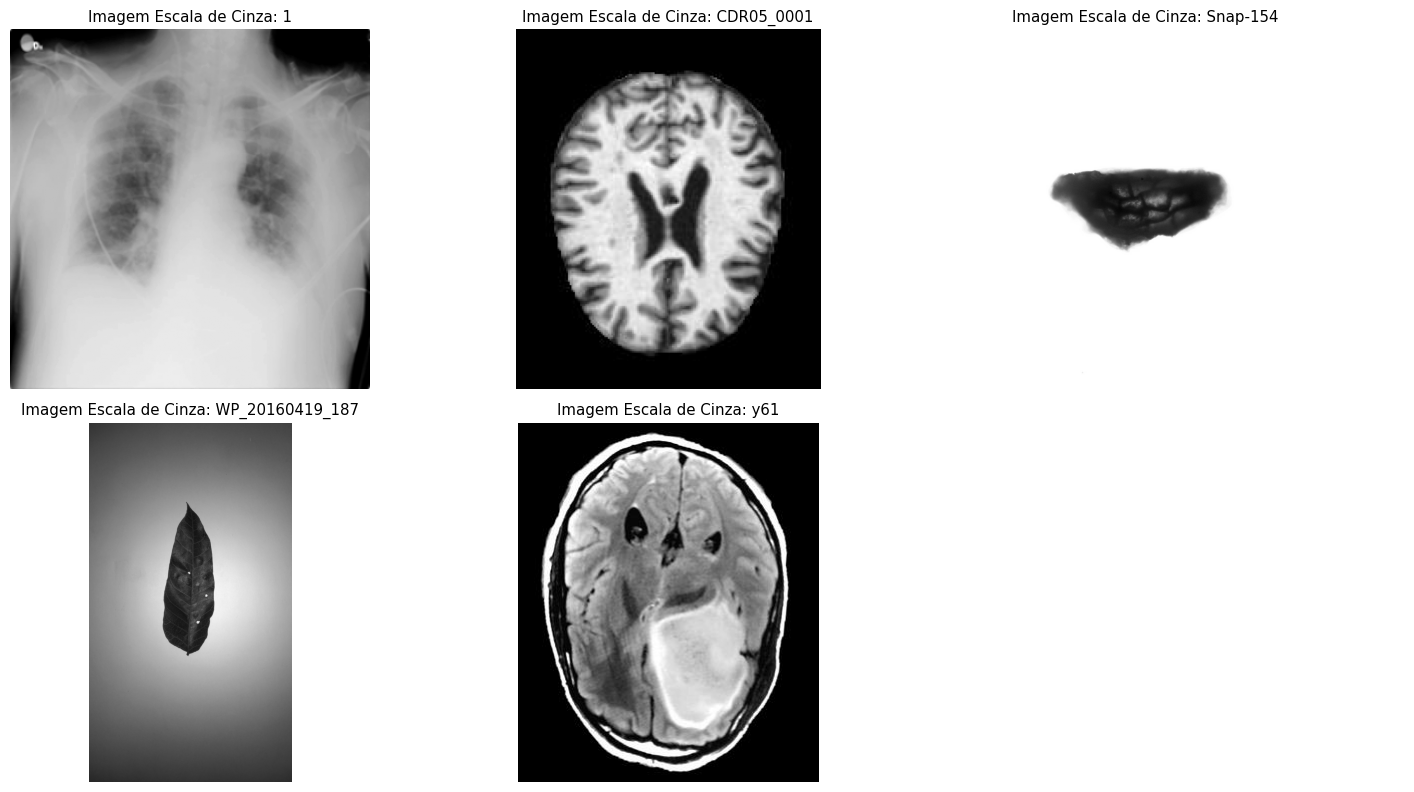

Item 1.4: Imagens em escala de cinza visualizadas com sucesso.


In [7]:
# Item 1.4: Visualização das imagens em escala de cinza
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for idx, (name, img_gray) in enumerate(sorted(images_gray.items())):
    axes[idx].imshow(img_gray, cmap='gray')
    axes[idx].set_title(f'Imagem Escala de Cinza: {name}')
    axes[idx].axis('off')

for idx in range(len(images_gray), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("Item 1.4: Imagens em escala de cinza visualizadas com sucesso.")

## Item 1.5 e 1.6: Requantização para 4, 2 e 1 bits

A requantização reduz o número de níveis de intensidade das imagens. Isso simula o efeito de reduzir a profundidade de bits (bit depth).

### Discussão:
- **4 bits**: 16 níveis de intensidade (0 a 15). Redução de 93.75% em relação aos 256 níveis originais
- **2 bits**: 4 níveis de intensidade (0, 85, 170, 255). Redução de 98.4%
- **1 bit**: 2 níveis (preto e branco). Máxima compressão com perda severa de informação

In [8]:
def requantize(img, bits):
    """Requantiza a imagem para o número especificado de bits."""
    max_value = 2**bits - 1
    # Dividir os valores originais (0-255) para o intervalo (0-max_value)
    requantized = (img.astype(float) / 255.0 * max_value).round().astype(np.uint8)
    # Remapear para 0-255 para visualização
    remapped = (requantized.astype(float) / max_value * 255).round().astype(np.uint8)
    return requantized, remapped

# Item 1.5: Requantização para 4 bits
images_4bits = {}
images_4bits_remapped = {}
for name, img_gray in images_gray.items():
    quant, remap = requantize(img_gray, 4)
    images_4bits[name] = quant
    images_4bits_remapped[name] = remap

# Item 1.6: Requantização para 2 e 1 bit
images_2bits = {}
images_2bits_remapped = {}
images_1bit = {}
images_1bit_remapped = {}

for name, img_gray in images_gray.items():
    quant2, remap2 = requantize(img_gray, 2)
    images_2bits[name] = quant2
    images_2bits_remapped[name] = remap2
    
    quant1, remap1 = requantize(img_gray, 1)
    images_1bit[name] = quant1
    images_1bit_remapped[name] = remap1

print("Item 1.5 e 1.6: Requantizações realizadas com sucesso.")

Item 1.5 e 1.6: Requantizações realizadas com sucesso.


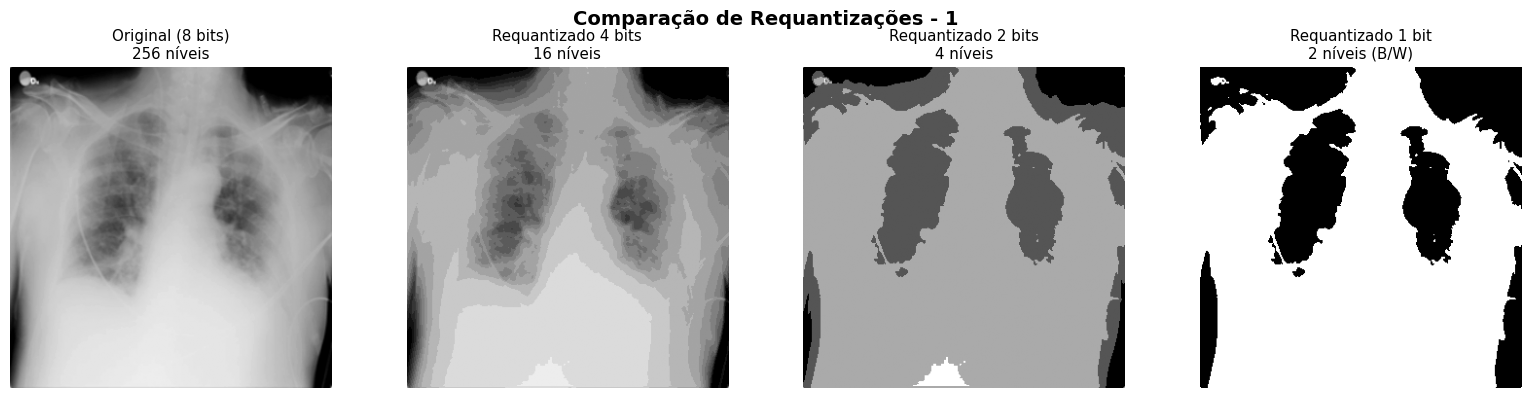

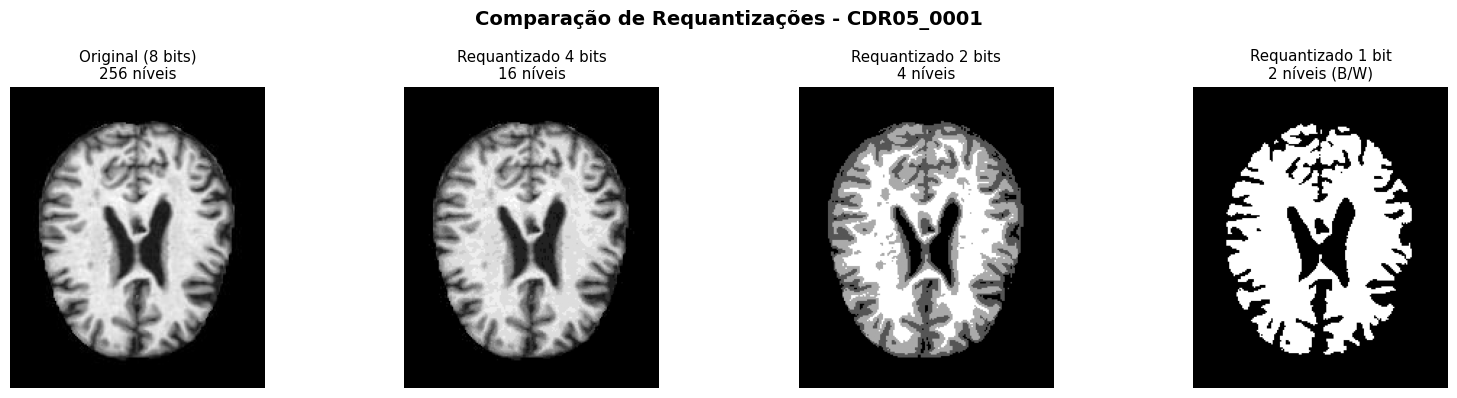

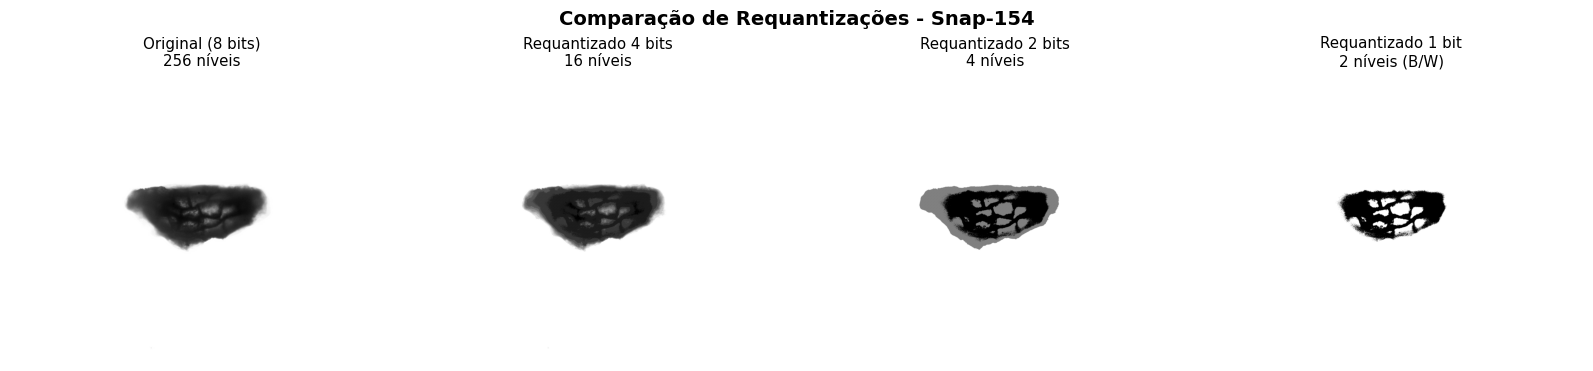

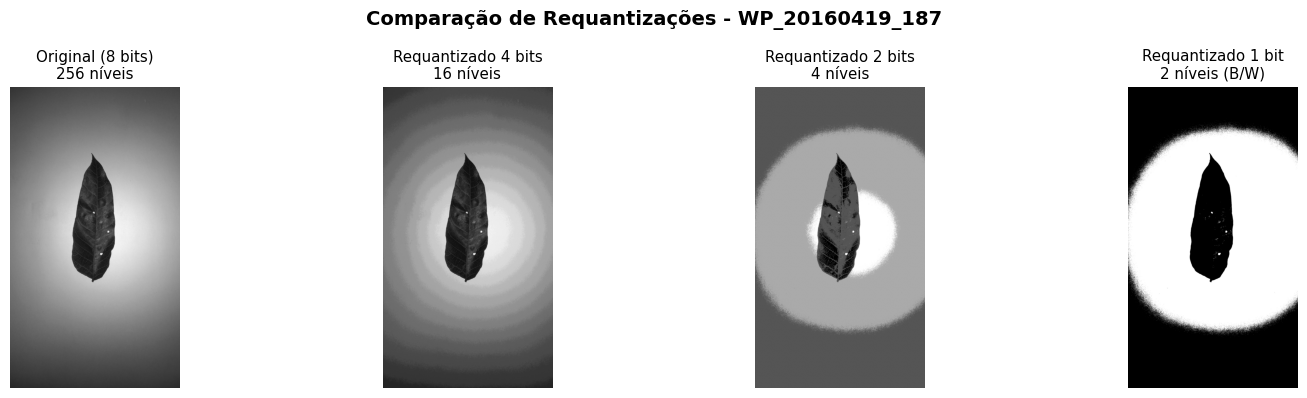

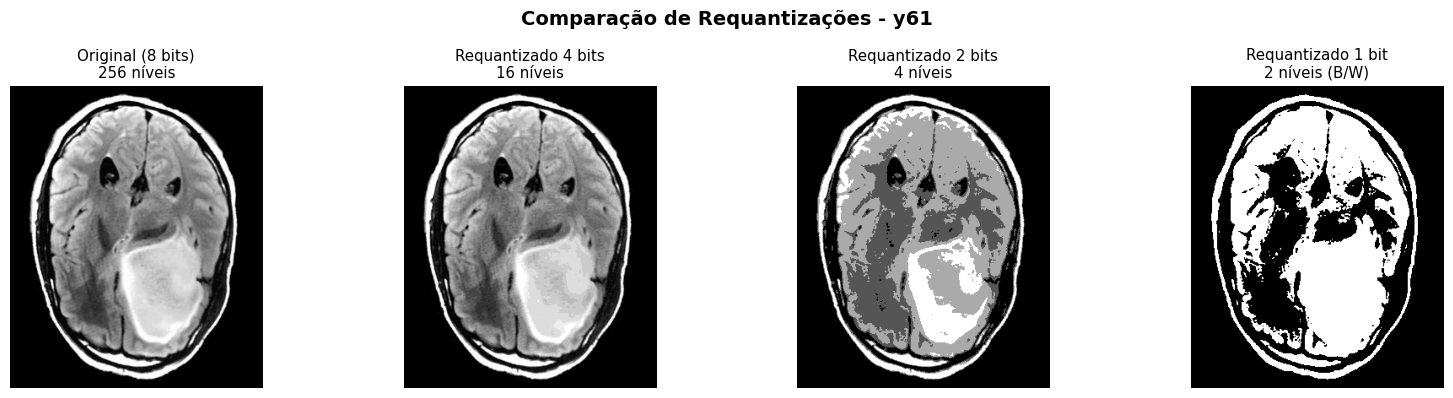

In [13]:
# Visualização das requantizações

for img in images_gray.keys():
    img_ref = images_gray[img]
    img_4b = images_4bits_remapped[img]
    img_2b = images_2bits_remapped[img]
    img_1b = images_1bit_remapped[img]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(img_ref, cmap='gray')
    axes[0].set_title('Original (8 bits)\n256 níveis')
    axes[0].axis('off')

    axes[1].imshow(img_4b, cmap='gray')
    axes[1].set_title('Requantizado 4 bits\n16 níveis')
    axes[1].axis('off')

    axes[2].imshow(img_2b, cmap='gray')
    axes[2].set_title('Requantizado 2 bits\n4 níveis')
    axes[2].axis('off')

    axes[3].imshow(img_1b, cmap='gray')
    axes[3].set_title('Requantizado 1 bit\n2 níveis (B/W)')
    axes[3].axis('off')

    plt.suptitle(f'Comparação de Requantizações - {img}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Discussão dos Resultados da Requantização

**Observações:**

1. **4 bits (16 níveis)**: A imagem mantém informação visual razoável. O efeito "posterização" é notável mas tolerable. Ainda conseguimos identificar estruturas principais da imagem.

2. **2 bits (4 níveis)**: A posterização se torna evidente com mudanças abruptas de tom. Muitos detalhes finos são perdidos, resultando em efeito de "bandas" de tons.

3. **1 bit (Preto e Branco)**: Máxima perda de informação. Apenas informação de bordas e formas grosseiras é preservada. Útil para detecção de contornos mas inútil para análise de texturas.

**Implicações estatísticas:**
- A requantização reduz a variância da imagem
- A entropia diminui progressivamente com a redução de bits
- O histograma se torna cada vez mais concentrado em poucos valores

## Item 1.7: Construção de Histogramas

O histograma é uma representação da distribuição de frequências dos valores de intensidade nas imagens.

1: Total de pixels = 109561
CDR05_0001: Total de pixels = 36608
Snap-154: Total de pixels = 4915200
WP_20160419_187: Total de pixels = 7104000
y61: Total de pixels = 107700


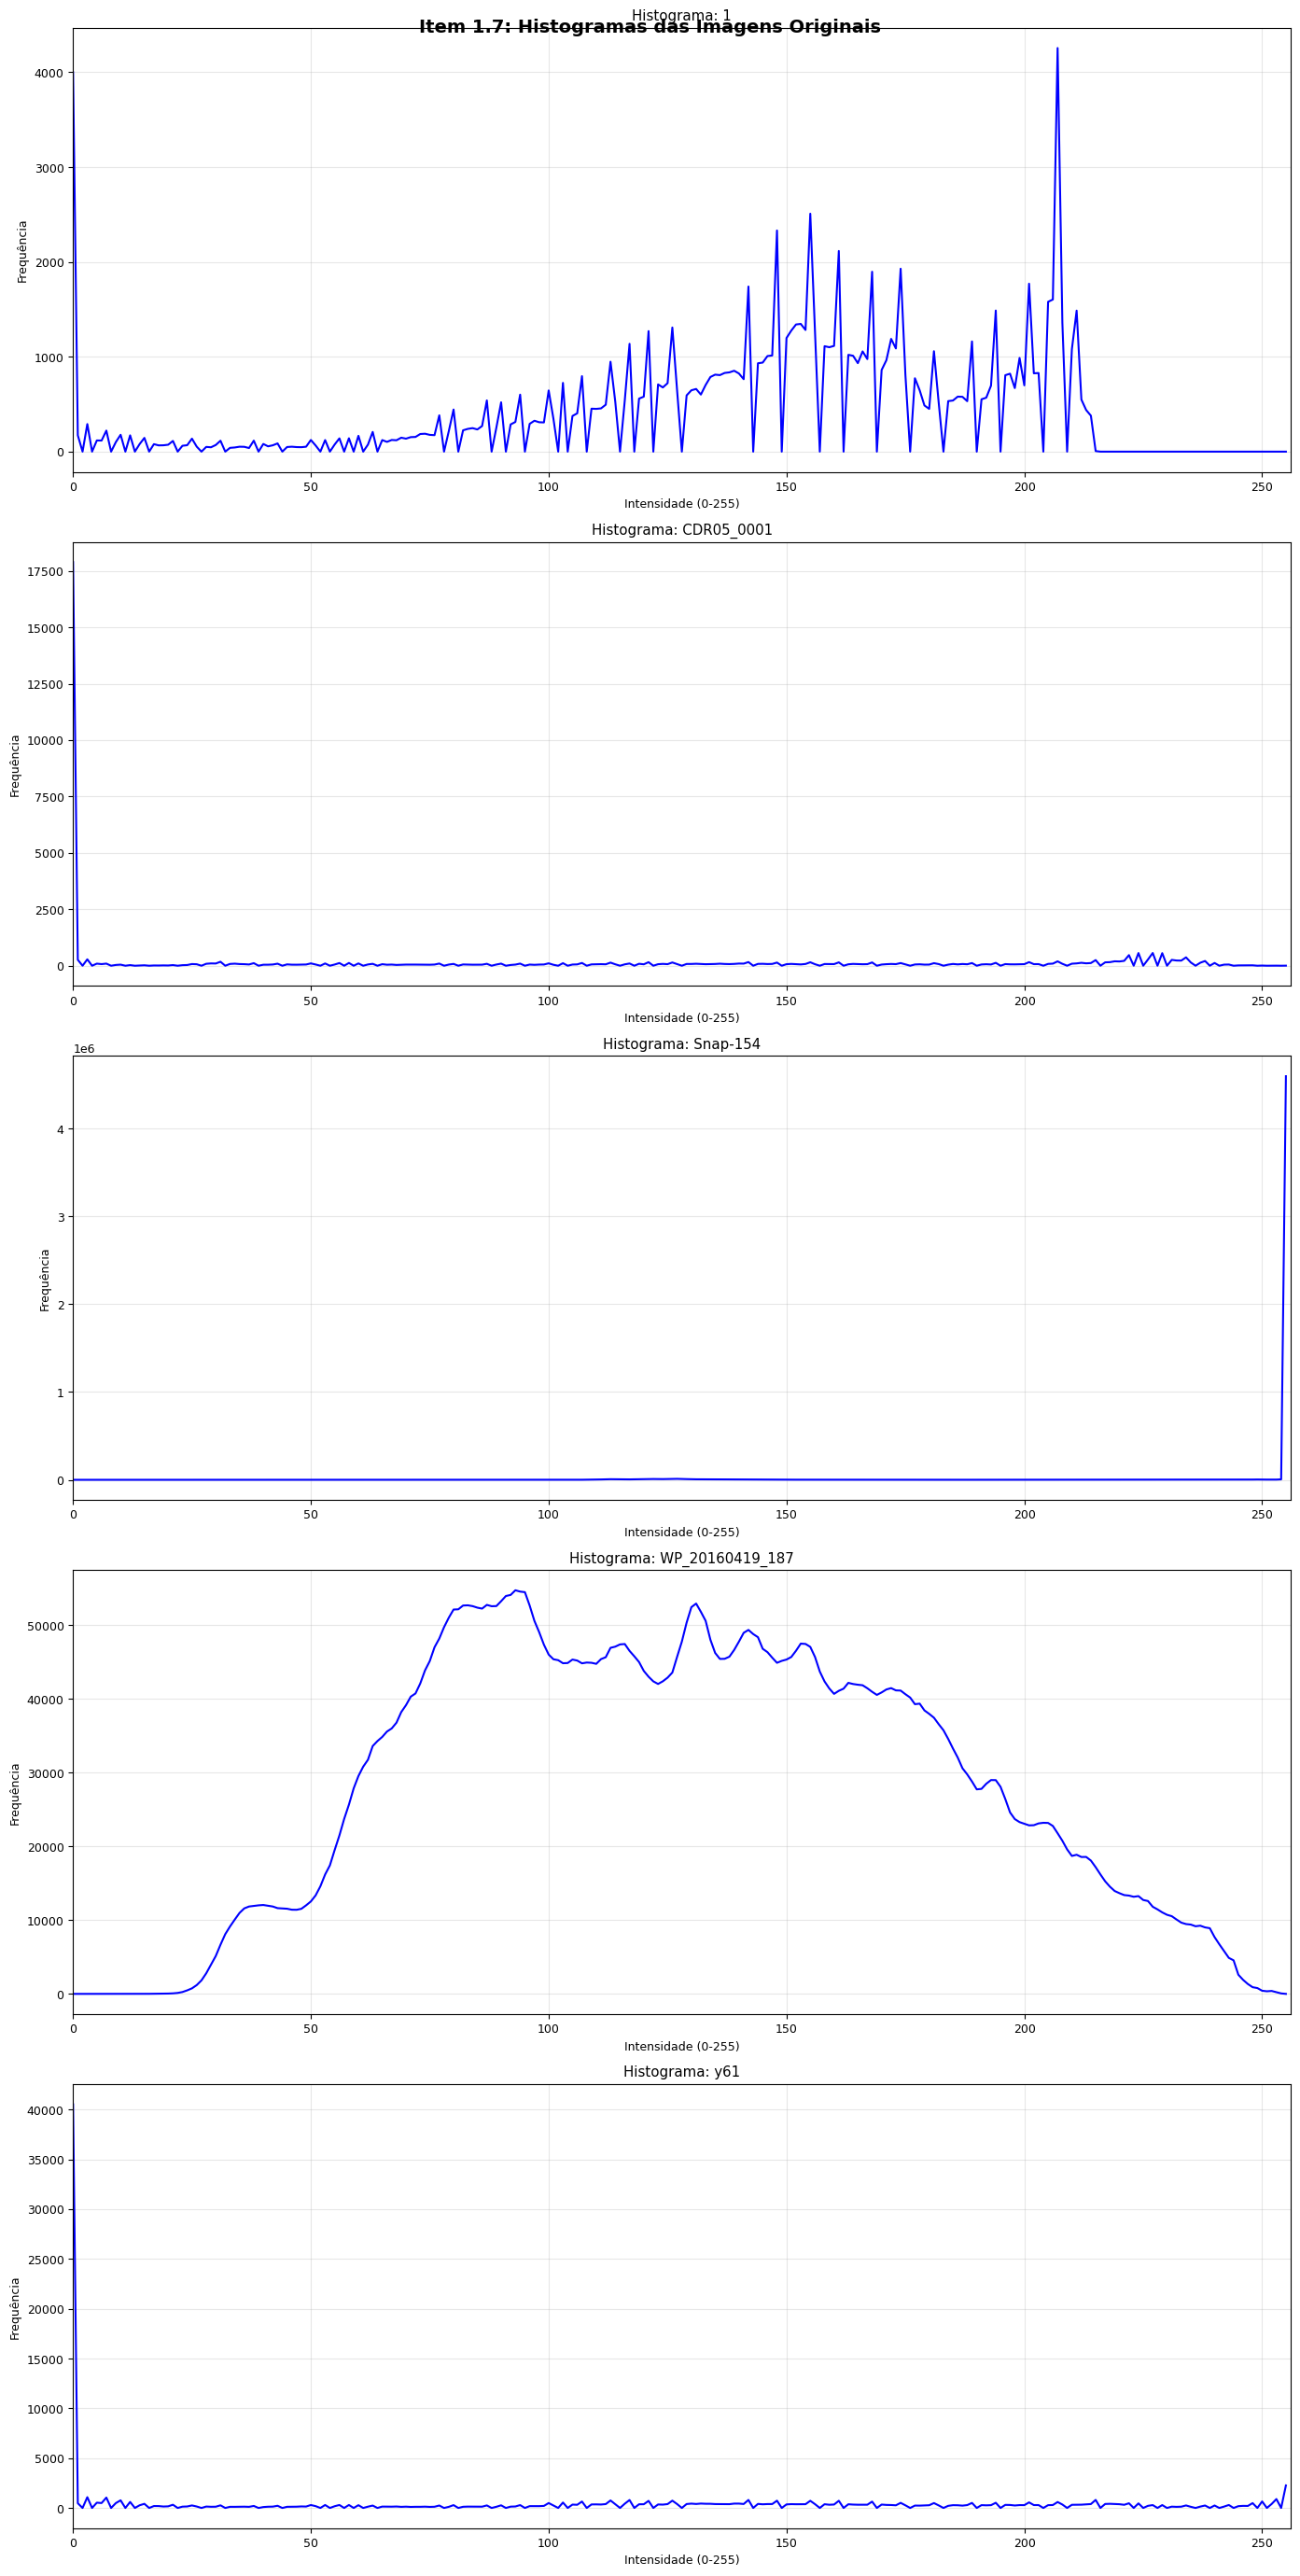

Item 1.7: Histogramas construídos com sucesso.


In [15]:
# Item 1.7: Construção de histogramas
histograms = {}
for name, img_gray in images_gray.items():
    # Calcular histograma (256 bins para 8 bits)
    hist, bins = np.histogram(img_gray, bins=256, range=(0, 256))
    histograms[name] = hist
    print(f"{name}: Total de pixels = {hist.sum()}")

# Visualizar histogramas
fig, axes = plt.subplots(len(histograms), 1, figsize=(14, 28))
axes = axes.flatten()

for idx, (name, hist) in enumerate(sorted(histograms.items())):
    axes[idx].plot(hist, color='blue', linewidth=1.5)
    axes[idx].set_title(f'Histograma: {name}')
    axes[idx].set_xlabel('Intensidade (0-255)')
    axes[idx].set_ylabel('Frequência')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(0, 256)

# Ocultar axes não utilizados se houver menos de 4 imagens
for idx in range(len(histograms), 4):
    axes[idx].axis('off')

plt.suptitle('Item 1.7: Histogramas das Imagens Originais', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Item 1.7: Histogramas construídos com sucesso.")

## Item 1.8: Normalização de Histogramas

A normalização divide cada histograma pela sua "área" (soma total de frequências), convertendo-o em uma Função de Densidade de Probabilidade (PDF) ou Probability Mass Function (PMF).


1:
  Soma original: 109561
  Soma normalizada: 1.000000
  Min (normalizado): 0.000000
  Max (normalizado): 0.038846

CDR05_0001:
  Soma original: 36608
  Soma normalizada: 1.000000
  Min (normalizado): 0.000000
  Max (normalizado): 0.488691

Snap-154:
  Soma original: 4915200
  Soma normalizada: 1.000000
  Min (normalizado): 0.000000
  Max (normalizado): 0.935180

WP_20160419_187:
  Soma original: 7104000
  Soma normalizada: 1.000000
  Min (normalizado): 0.000000
  Max (normalizado): 0.007708

y61:
  Soma original: 107700
  Soma normalizada: 1.000000
  Min (normalizado): 0.000000
  Max (normalizado): 0.376277


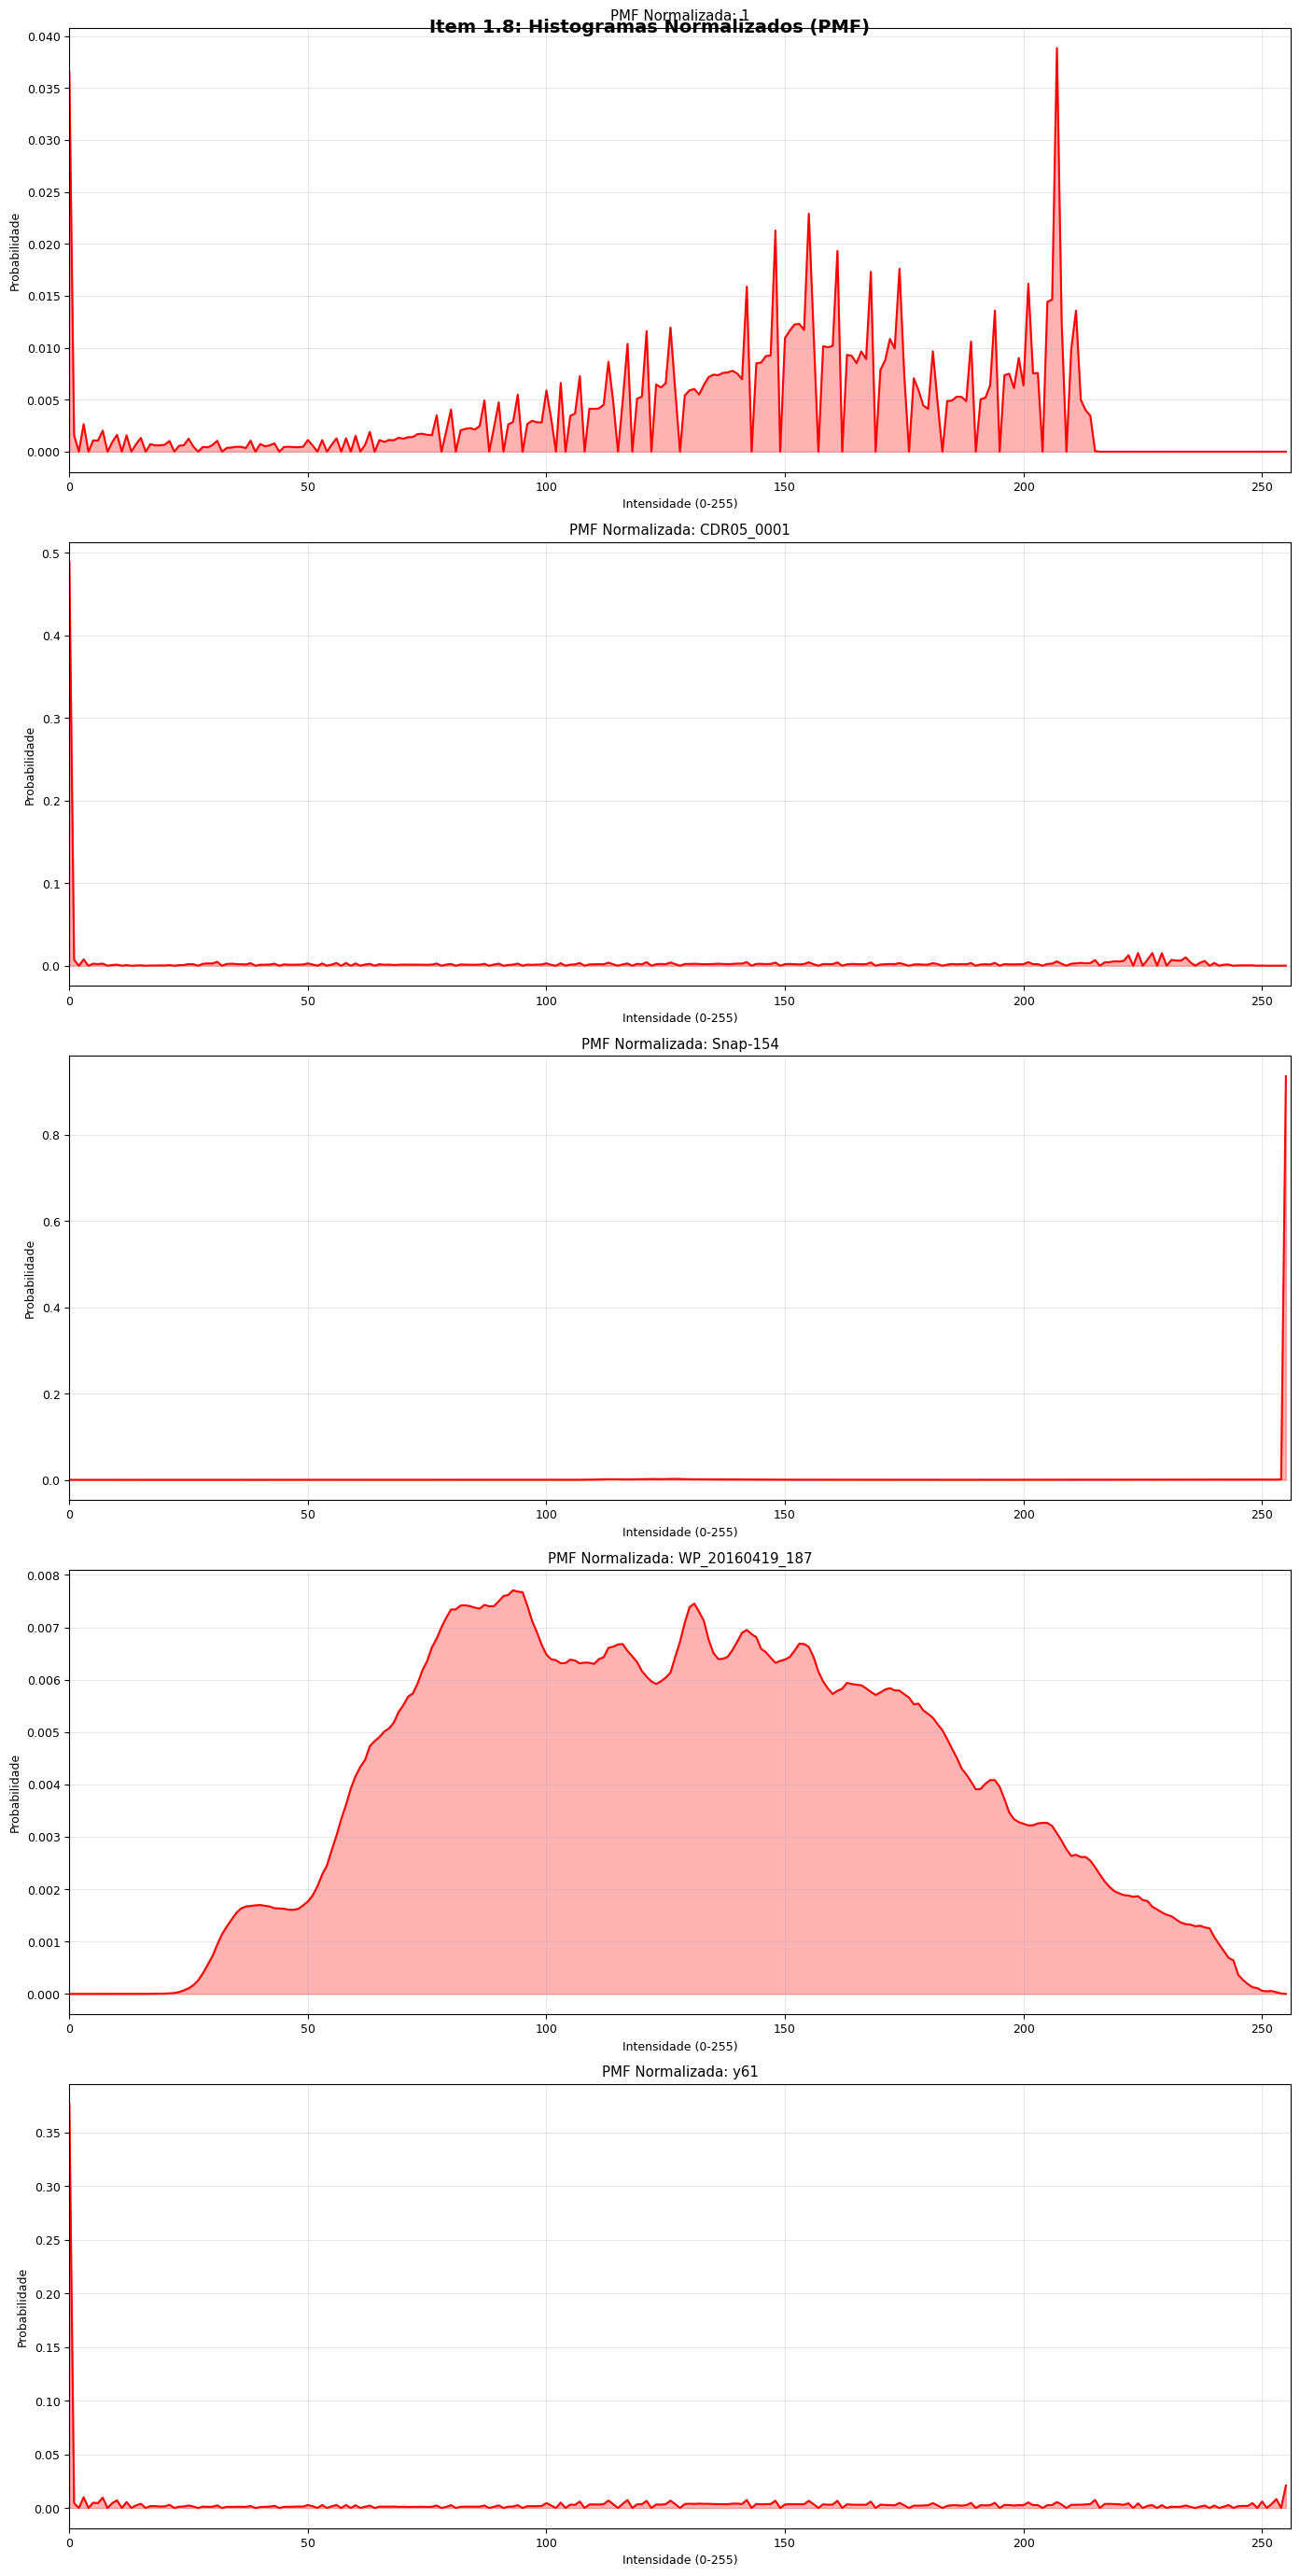


Item 1.8: Histogramas normalizados com sucesso.


In [16]:
# Item 1.8: Normalização dos histogramas
histograms_normalized = {}
for name, hist in histograms.items():
    # Normalizar pela área (soma total)
    total = hist.sum()
    hist_norm = hist / total
    histograms_normalized[name] = hist_norm
    
    # Calcular estatísticas
    print(f"\n{name}:")
    print(f"  Soma original: {total}")
    print(f"  Soma normalizada: {hist_norm.sum():.6f}")
    print(f"  Min (normalizado): {hist_norm.min():.6f}")
    print(f"  Max (normalizado): {hist_norm.max():.6f}")

# Visualizar histogramas normalizados
fig, axes = plt.subplots(len(histograms_normalized), 1, figsize=(14, 28))
axes = axes.flatten()

for idx, (name, hist_norm) in enumerate(sorted(histograms_normalized.items())):
    axes[idx].plot(hist_norm, color='red', linewidth=1.5)
    axes[idx].fill_between(range(len(hist_norm)), hist_norm, alpha=0.3, color='red')
    axes[idx].set_title(f'PMF Normalizada: {name}')
    axes[idx].set_xlabel('Intensidade (0-255)')
    axes[idx].set_ylabel('Probabilidade')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(0, 256)

for idx in range(len(histograms_normalized), 4):
    axes[idx].axis('off')

plt.suptitle('Item 1.8: Histogramas Normalizados (PMF)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nItem 1.8: Histogramas normalizados com sucesso.")

## Discussão Final e Conclusões

### Resumo das Atividades Realizadas

1. **Itens 1.1-1.2**: Carregamos com sucesso as imagens do diretório e as visualizamos em cores RGB.

2. **Item 1.3**: Convertemos as imagens para escala de cinza usando a transformação de luminância padrão (ITU-R BT.601), que pondera os canais RGB para simular a percepção visual humana.

3. **Item 1.4**: Visualizamos as imagens em escala de cinza, confirmando que a conversão foi realizada corretamente.

4. **Items 1.5-1.6**: Realizamos requantização para 4, 2 e 1 bits. Observamos que:
   - **4 bits** mantém informação razoável com posterização leve
   - **2 bits** introduce artefatos significativos
   - **1 bit** resulta em imagem binária pura, apropriada para detecção de bordas

5. **Item 1.7**: Construímos histogramas mostrando a distribuição de frequências de intensidades em cada imagem.

6. **Item 1.8**: Normalizamos os histogramas pela área total, convertendo-os em Funções de Massa de Probabilidade (PMF), onde a soma é 1.

### Observações Importantes

- **Variância Estatística**: A requantização reduz significativamente a variância das imagens
- **Entropia**: Com menor bit depth, a entropia de Shannon diminui
- **Preservação de Informação**: O algoritmo de requantização preserva as relações de luminância relativa

### Aplicações Práticas

Os histogramas normalizados servem como base para:
- Análise de características estatísticas
- Processamento de imagens adaptativo
- Classificação de imagens (trabalhos posteriores)